Data shape: (100000, 14)
Training set shape: (80000, 12)
Testing set shape: (20000, 12)

=== Training Base LightGBM Model ===
Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 0.648651
[20]	valid_0's rmse: 0.442925
[30]	valid_0's rmse: 0.326716
[40]	valid_0's rmse: 0.271549
[50]	valid_0's rmse: 0.247095
[60]	valid_0's rmse: 0.23751
[70]	valid_0's rmse: 0.233412
[80]	valid_0's rmse: 0.231704
[90]	valid_0's rmse: 0.230902
[100]	valid_0's rmse: 0.230774
[110]	valid_0's rmse: 0.230732
[120]	valid_0's rmse: 0.230685
[130]	valid_0's rmse: 0.230741
[140]	valid_0's rmse: 0.230769
[150]	valid_0's rmse: 0.230785
[160]	valid_0's rmse: 0.230775
[170]	valid_0's rmse: 0.230989
Early stopping, best iteration is:
[123]	valid_0's rmse: 0.230619
Base model training time: 0.35 seconds
--- Base LightGBM Model Performance Metrics ---
RMSE: 0.23
R² Score: 0.9471
MAPE: 27.10%
Prediction Accuracy: 72.90%


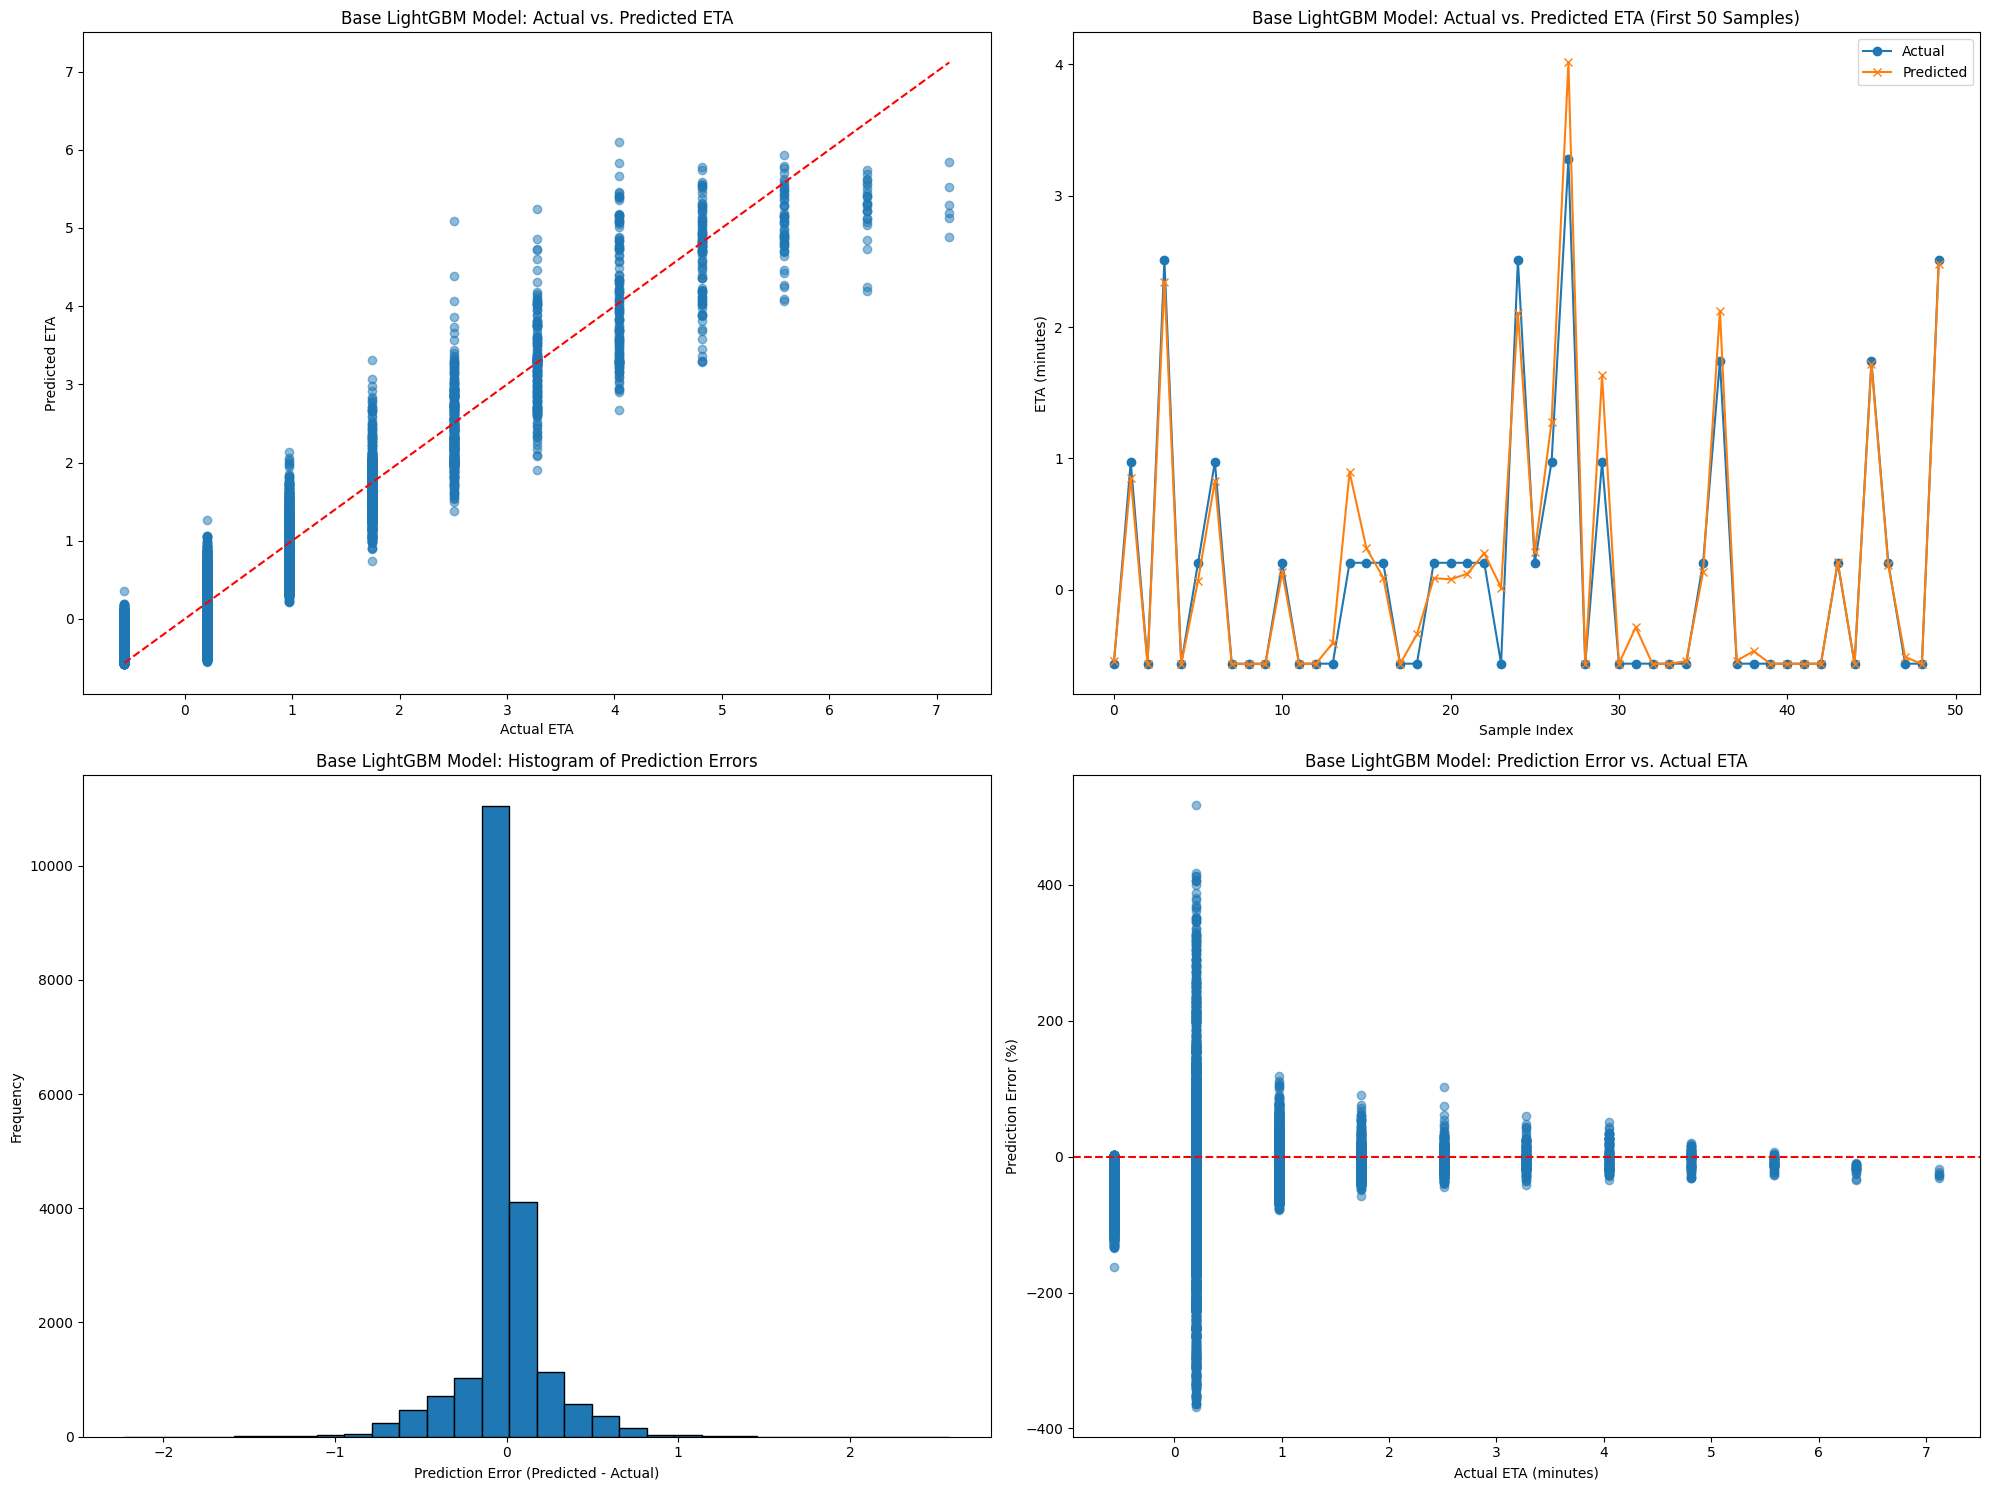


=== Performing Hyperparameter Tuning ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Hyperparameter tuning completed in 44.70 seconds
Best parameters: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best RMSE: 0.2343

=== Training Optimized LightGBM Model ===
Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 0.680167
[20]	valid_0's rmse: 0.514747
[30]	valid_0's rmse: 0.399794
[40]	valid_0's rmse: 0.325781
[50]	valid_0's rmse: 0.284264
[60]	valid_0's rmse: 0.274344
[70]	valid_0's rmse: 0.258461
[80]	valid_0's rmse: 0.247681
[90]	valid_0's rmse: 0.241357
[100]	valid_0's rmse: 0.237528
[110]	valid_0's rmse: 0.235861
[120]	valid_0's rmse: 0.23404
[130]	valid_0's rmse: 0.233077
[140]	valid_0's rmse: 0.232408
[150]	valid_0's rmse: 0.232146
[160]	valid_0's rmse: 0.231833
[170]	valid_0's rmse: 0.231447
[180]	va

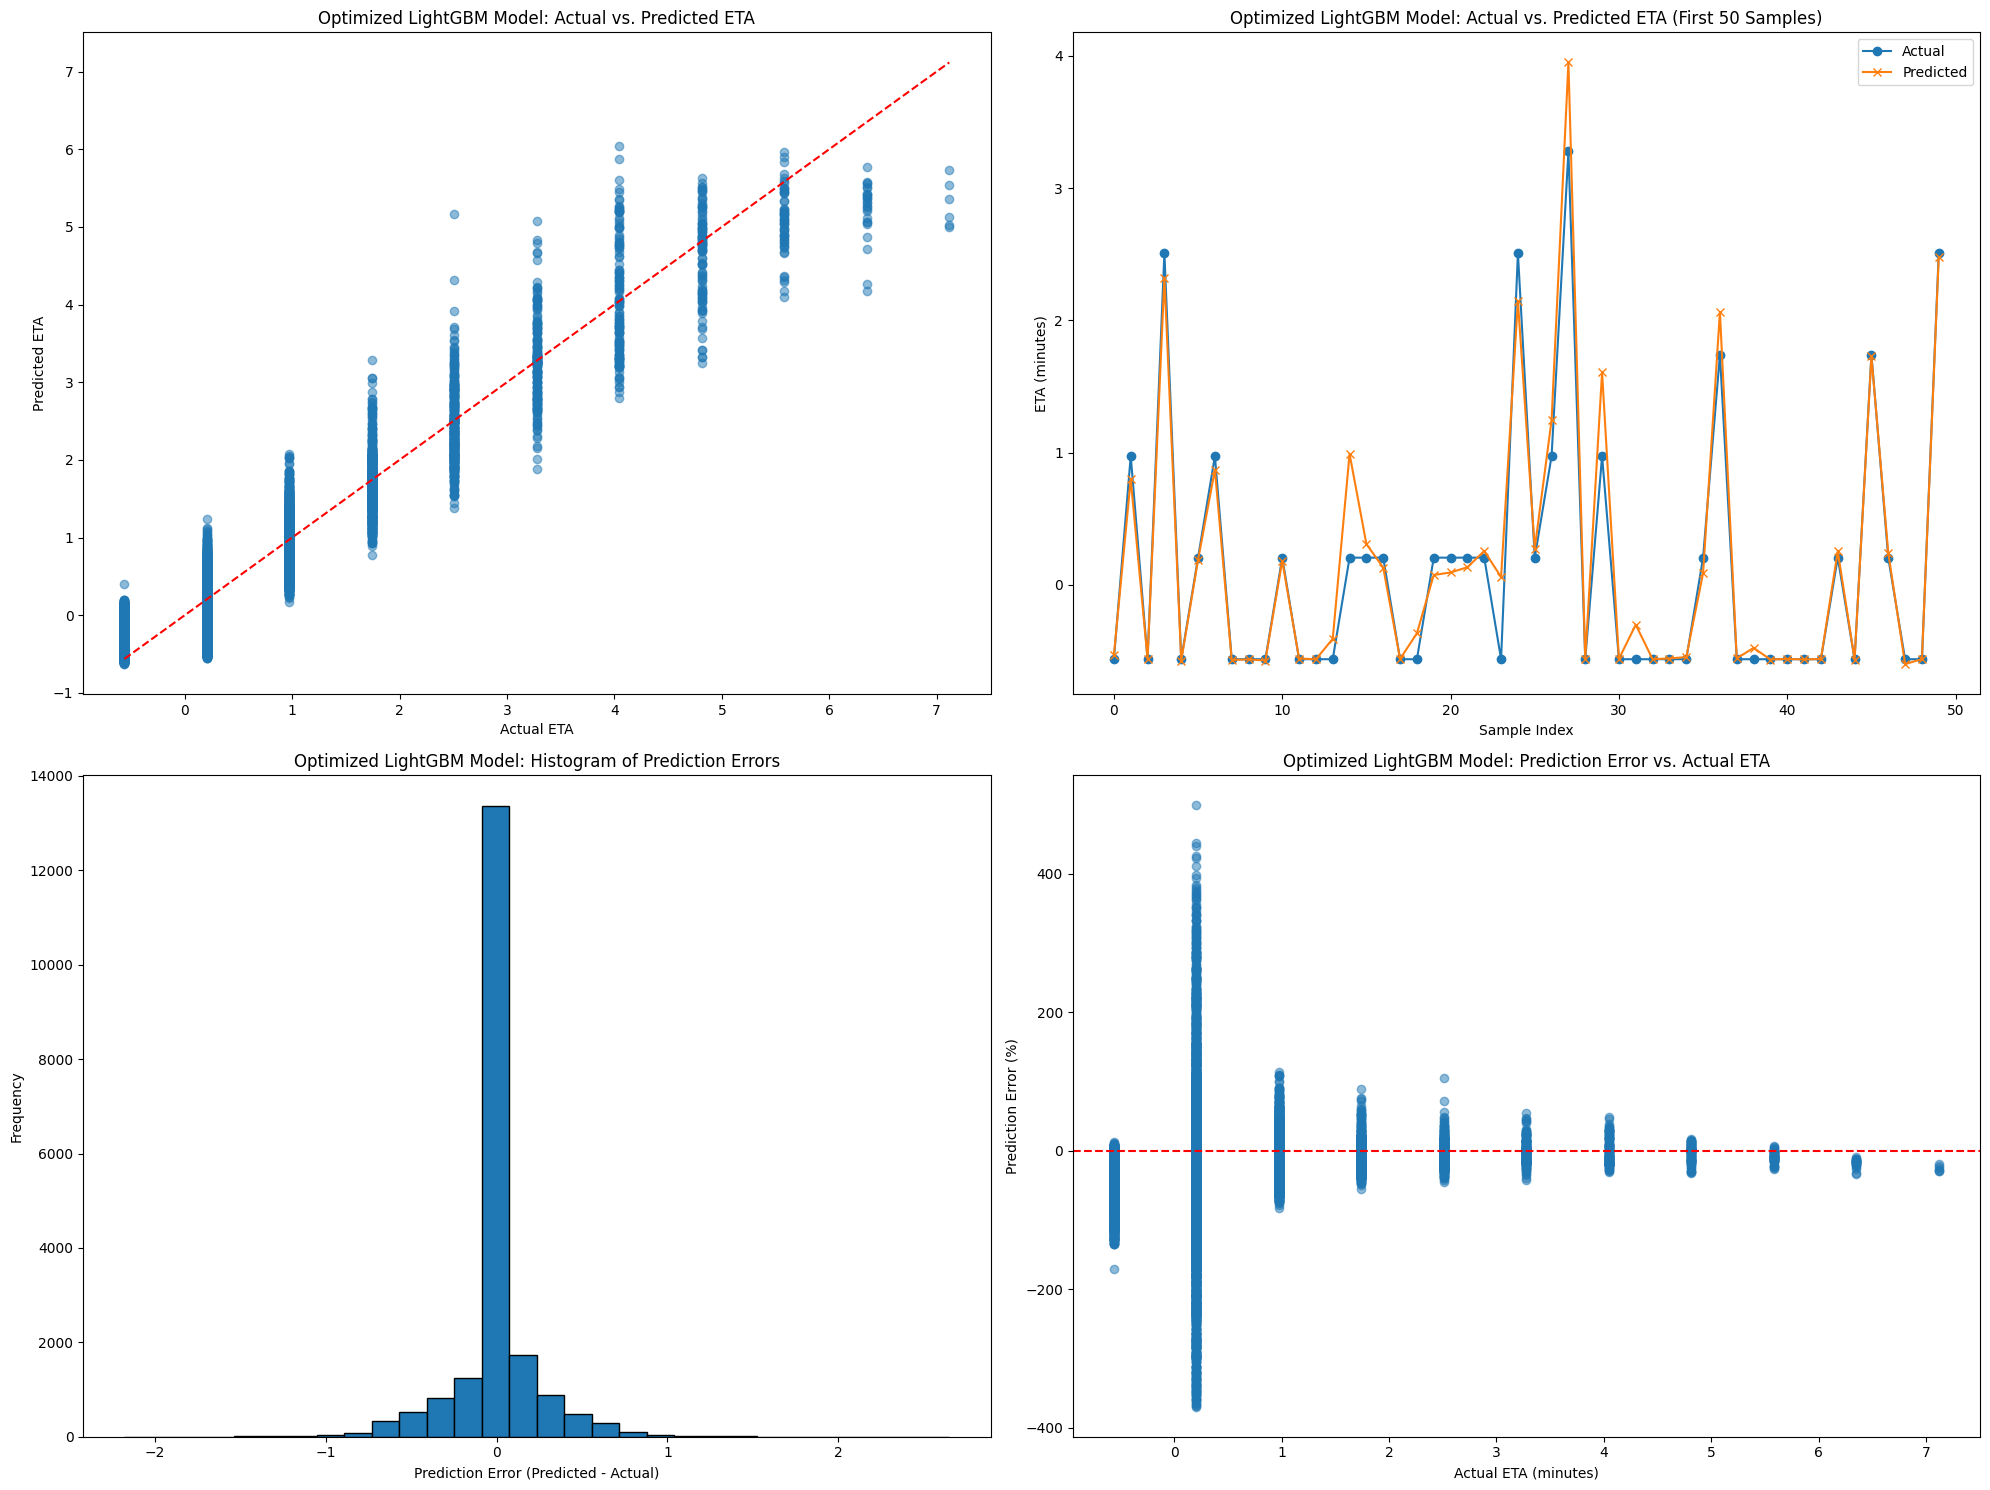


=== Performance Comparison ===
Metric               Base Model      Optimized Model Improvement    
-----------------------------------------------------------------
RMSE                 0.2306          0.2304          0.09%          
R² Score             0.9471          0.9472          0.01%          
MAPE                 27.0995         26.9245         0.65%          
Accuracy             72.9005         73.0755         0.24%          
Training Time (s)    0.3460          0.6790          -96.25%        


<Figure size 1200x800 with 0 Axes>

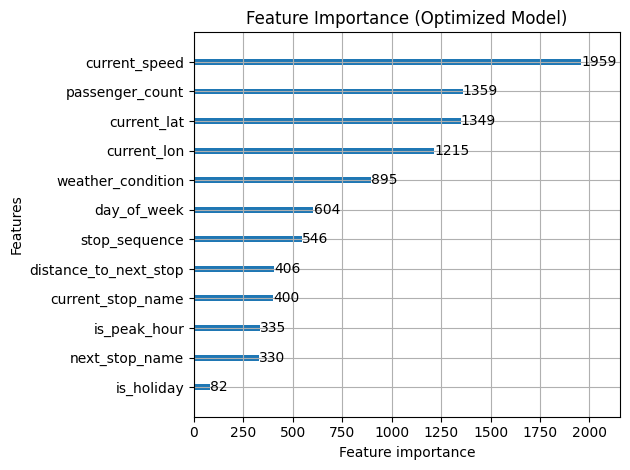

Optimized model saved as 'lightgbm_optimized_model.txt'


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Use the same dataset you already loaded
df = pd.read_csv('bus_eta_standard_scaled.csv')

print("Data shape:", df.shape)

# Selecting features and target variable
X = df.drop(columns=['timestamp', 'eta_minutes'])  # Features
y = df['eta_minutes']  # Target

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Function to evaluate and visualize model performance
def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    accuracy = 100 - mape
    
    print(f"--- {model_name} Performance Metrics ---")
    print(f'RMSE: {rmse:.2f}')
    print(f'R² Score: {r2:.4f}')
    print(f"MAPE: {mape:.2f}%")
    print(f"Prediction Accuracy: {accuracy:.2f}%")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Scatter plot of actual vs predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--')
    axes[0, 0].set_xlabel("Actual ETA")
    axes[0, 0].set_ylabel("Predicted ETA")
    axes[0, 0].set_title(f"{model_name}: Actual vs. Predicted ETA")
    
    # Line plot of first 50 samples
    axes[0, 1].plot(y_test.values[:50], label="Actual", marker='o')
    axes[0, 1].plot(y_pred[:50], label="Predicted", marker='x')
    axes[0, 1].set_xlabel("Sample Index")
    axes[0, 1].set_ylabel("ETA (minutes)")
    axes[0, 1].set_title(f"{model_name}: Actual vs. Predicted ETA (First 50 Samples)")
    axes[0, 1].legend()
    
    # Histogram of errors
    errors = y_pred - y_test
    axes[1, 0].hist(errors, bins=30, edgecolor='black')
    axes[1, 0].set_xlabel("Prediction Error (Predicted - Actual)")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title(f"{model_name}: Histogram of Prediction Errors")
    
    # Percentage error vs actual
    percentage_error = 100 * (y_pred - y_test) / y_test
    axes[1, 1].scatter(y_test, percentage_error, alpha=0.5)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel("Actual ETA (minutes)")
    axes[1, 1].set_ylabel("Prediction Error (%)")
    axes[1, 1].set_title(f"{model_name}: Prediction Error vs. Actual ETA")
    
    plt.tight_layout()
    plt.show()
    
    return {
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'accuracy': accuracy,
        'predictions': y_pred
    }

# Step 1: Create a basic LightGBM model (CPU only)
print("\n=== Training Base LightGBM Model ===")

# Create LGB datasets for faster training
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

# Base parameters - no GPU parameters
base_params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

# Train the base model and measure time
start_time = time.time()
try:
    # First try the newer callback syntax
    base_model = lgb.train(
        base_params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_eval],
        callbacks=[
            lgb.callback.early_stopping(stopping_rounds=50, verbose=True),
            lgb.callback.log_evaluation(period=10)
        ]
    )
except AttributeError:
    # If that fails, try the older syntax
    base_model = lgb.train(
        base_params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_eval],
        early_stopping_rounds=50,
        verbose_eval=10
    )
    
base_training_time = time.time() - start_time
print(f"Base model training time: {base_training_time:.2f} seconds")

# Evaluate the base model
base_results = evaluate_model(base_model, X_test, y_test, "Base LightGBM Model")

# Step 2: Hyperparameter tuning with RandomizedSearchCV
print("\n=== Performing Hyperparameter Tuning ===")

# Create the LightGBM model for tuning (CPU only)
lgb_model = lgb.LGBMRegressor(verbose=-1)

# Define the hyperparameter search space
param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [5, 10, 20, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Perform the hyperparameter tuning
start_time = time.time()
random_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {tuning_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best RMSE: {np.sqrt(-random_search.best_score_):.4f}")

# Train the optimized model with the best parameters
print("\n=== Training Optimized LightGBM Model ===")

# Get the best parameters (no GPU parameters)
best_params = random_search.best_params_.copy()
best_params['objective'] = 'regression'
best_params['metric'] = 'rmse'
best_params['verbose'] = -1

# Extract n_estimators and remove it from params (it's used differently in lgb.train)
n_estimators = best_params.pop('n_estimators')

# Train the optimized model
start_time = time.time()
try:
    # First try the newer callback syntax
    optimized_model = lgb.train(
        best_params,
        lgb_train,
        num_boost_round=n_estimators,
        valid_sets=[lgb_eval],
        callbacks=[
            lgb.callback.early_stopping(stopping_rounds=50, verbose=True),
            lgb.callback.log_evaluation(period=10)
        ]
    )
except AttributeError:
    # If that fails, try the older syntax
    optimized_model = lgb.train(
        best_params,
        lgb_train,
        num_boost_round=n_estimators,
        valid_sets=[lgb_eval],
        early_stopping_rounds=50,
        verbose_eval=10
    )
    
optimized_training_time = time.time() - start_time
print(f"Optimized model training time: {optimized_training_time:.2f} seconds")

# Evaluate the optimized model
optimized_results = evaluate_model(optimized_model, X_test, y_test, "Optimized LightGBM Model")

# Compare the performance of base and optimized models
print("\n=== Performance Comparison ===")
print(f"{'Metric':<20} {'Base Model':<15} {'Optimized Model':<15} {'Improvement':<15}")
print("-" * 65)
metrics = [
    ('RMSE', base_results['rmse'], optimized_results['rmse'], 
     f"{(base_results['rmse'] - optimized_results['rmse'])/base_results['rmse']*100:.2f}%"),
    ('R² Score', base_results['r2'], optimized_results['r2'], 
     f"{(optimized_results['r2'] - base_results['r2'])/abs(base_results['r2'])*100:.2f}%"),
    ('MAPE', base_results['mape'], optimized_results['mape'], 
     f"{(base_results['mape'] - optimized_results['mape'])/base_results['mape']*100:.2f}%"),
    ('Accuracy', base_results['accuracy'], optimized_results['accuracy'], 
     f"{(optimized_results['accuracy'] - base_results['accuracy'])/base_results['accuracy']*100:.2f}%"),
    ('Training Time (s)', base_training_time, optimized_training_time, 
     f"{(base_training_time - optimized_training_time)/base_training_time*100:.2f}%")
]

for metric, base, optimized, improvement in metrics:
    print(f"{metric:<20} {base:<15.4f} {optimized:<15.4f} {improvement:<15}")

# Feature importance plot
plt.figure(figsize=(12, 8))
lgb.plot_importance(optimized_model, max_num_features=20)
plt.title('Feature Importance (Optimized Model)')
plt.tight_layout()
plt.show()

# Save the optimized model
optimized_model.save_model('lightgbm_optimized_model.txt')
print("Optimized model saved as 'lightgbm_optimized_model.txt'")

Prediction Results for 20 Random Samples (in whole minutes):
    Actual_ETA_Minutes  Predicted_ETA_Minutes  Difference_Minutes
0                    0                      0                   0
1                    0                      0                   0
2                    5                      4                  -1
3                    0                      0                   0
4                    0                      0                   0
5                    1                      1                   0
6                    2                      2                   0
7                    0                      0                   0
8                    0                      0                   0
9                    3                      3                   0
10                   1                      1                   0
11                   0                      0                   0
12                   0                      0                   0
13             

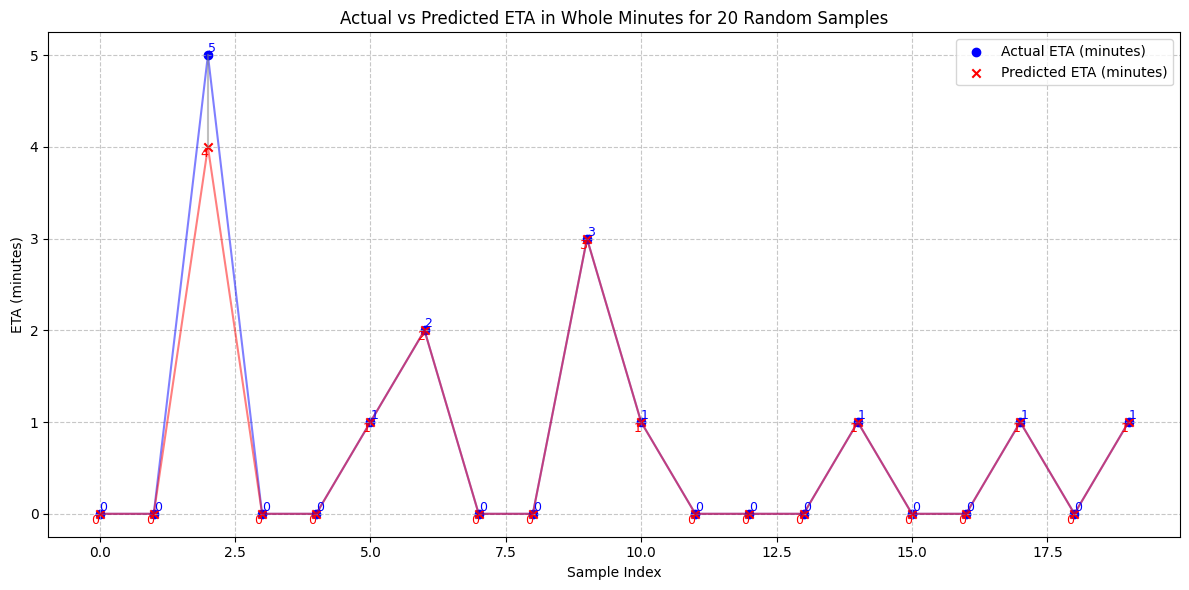


Accuracy Metrics for Whole Minutes:
Exact minute match: 95.00%
Within ±1 minute: 100.00%
Within ±3 minutes: 100.00%
Mean absolute error: 0.05 minutes


In [3]:
# Load the saved optimized model
loaded_model = lgb.Booster(model_file='lightgbm_optimized_model.txt')

# Get 20 samples from the test data
sample_indices = np.random.choice(len(X_test), size=20, replace=False)
X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]

# Make predictions using the loaded model
y_pred_sample = loaded_model.predict(X_sample)

# Since we need to inverse transform the predictions to get actual minutes
# We need to load the scaler used for the target variable or estimate parameters
import joblib

try:
    # Try to load the saved scaler
    y_scaler = joblib.load('eta_standard_scaler.joblib')
    
    # Reshape predictions and actual values for inverse transform
    y_pred_unscaled = y_scaler.inverse_transform(y_pred_sample.reshape(-1, 1)).flatten()
    y_sample_unscaled = y_scaler.inverse_transform(y_sample.values.reshape(-1, 1)).flatten()
    
except (FileNotFoundError, ValueError):
    # If scaler not available, we can estimate the scaling parameters from the data
    print("Scaler not found. Using approximation based on the dataset statistics.")
    
    # Attempt to load original unscaled data
    try:
        original_unscaled_df = pd.read_csv('bus_eta.csv')
        eta_mean = original_unscaled_df['eta_minutes'].mean()
        eta_std = original_unscaled_df['eta_minutes'].std()
    except FileNotFoundError:
        # Estimate mean and std based on available information
        print("Using estimated scaling parameters. Replace with actual values if known.")
        eta_mean = 0  # Assuming StandardScaler was applied (mean becomes 0)
        eta_std = 1   # Assuming StandardScaler was applied (std becomes 1)
    
    # Inverse transform function
    y_pred_unscaled = y_pred_sample * eta_std + eta_mean
    y_sample_unscaled = y_sample.values * eta_std + eta_mean

# Round to nearest whole minute
y_pred_minutes = np.round(y_pred_unscaled).astype(int)
y_actual_minutes = np.round(y_sample_unscaled).astype(int)

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Actual_ETA_Minutes': y_actual_minutes,
    'Predicted_ETA_Minutes': y_pred_minutes,
    'Difference_Minutes': y_pred_minutes - y_actual_minutes
})

# Display the results
print("Prediction Results for 20 Random Samples (in whole minutes):")
print(results_df)

# Visualize the results with whole minutes
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_actual_minutes)), y_actual_minutes, color='blue', marker='o', label='Actual ETA (minutes)')
plt.scatter(range(len(y_pred_minutes)), y_pred_minutes, color='red', marker='x', label='Predicted ETA (minutes)')
plt.plot(range(len(y_actual_minutes)), y_actual_minutes, color='blue', alpha=0.5)
plt.plot(range(len(y_pred_minutes)), y_pred_minutes, color='red', alpha=0.5)

plt.title('Actual vs Predicted ETA in Whole Minutes for 20 Random Samples')
plt.xlabel('Sample Index')
plt.ylabel('ETA (minutes)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Add text labels showing the exact minute values
for i, (actual, pred) in enumerate(zip(y_actual_minutes, y_pred_minutes)):
    plt.text(i, actual, f"{actual}", fontsize=9, ha='left', va='bottom', color='blue')
    plt.text(i, pred, f"{pred}", fontsize=9, ha='right', va='top', color='red')

# Add error bars
for i in range(len(y_actual_minutes)):
    plt.plot([i, i], [y_actual_minutes[i], y_pred_minutes[i]], color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

# Calculate accuracy metrics
exact_match = np.sum(y_pred_minutes == y_actual_minutes) / len(y_actual_minutes) * 100
within_1_min = np.sum(np.abs(y_pred_minutes - y_actual_minutes) <= 1) / len(y_actual_minutes) * 100
within_3_min = np.sum(np.abs(y_pred_minutes - y_actual_minutes) <= 3) / len(y_actual_minutes) * 100

print("\nAccuracy Metrics for Whole Minutes:")
print(f"Exact minute match: {exact_match:.2f}%")
print(f"Within ±1 minute: {within_1_min:.2f}%")
print(f"Within ±3 minutes: {within_3_min:.2f}%")
print(f"Mean absolute error: {np.mean(np.abs(y_pred_minutes - y_actual_minutes)):.2f} minutes")